### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [93]:
data = pd.read_csv('data/coupons.csv')

In [94]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [95]:
# Look for missing data
data.info()
# Count missing rows
data.isna().sum()
# Consider dropping columns if too many are null
(data.isna().sum() / len(data)) * 100
# Look for blank values - found none
(data == "").sum()
# Describe data to look for anything odd
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


3. Decide what to do about your missing data -- drop, replace, other...

In [96]:
# 99.14% of car data is missing, let's drop that column
data = data.drop(columns=['car'])

4. What proportion of the total observations chose to accept the coupon?



In [97]:
num_use_coupon = (data['Y'] == 1).sum()
total = len(data)
ratio = (num_use_coupon / total) * 100
print('Percentage of data where coupon used: ', ratio, '%')

Percentage of data where coupon used:  56.84326710816777 %


5. Use a bar plot to visualize the `coupon` column.

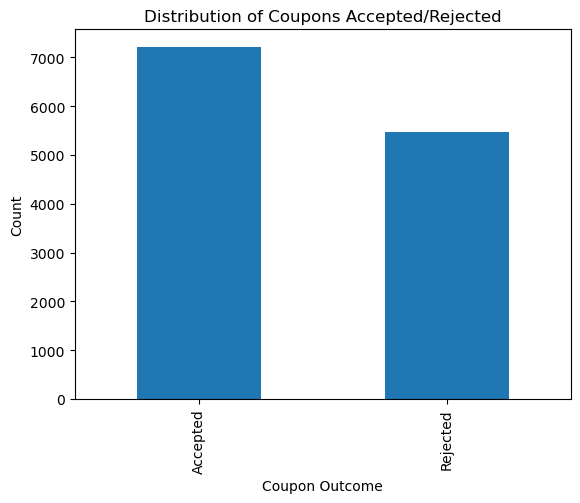

In [98]:
labels = {
    1: 'Accepted',
    0: 'Rejected'
}

data['Y'].map(labels).value_counts().plot(kind='bar')
plt.title('Distribution of Coupons Accepted/Rejected')
plt.xlabel('Coupon Outcome')
plt.ylabel('Count')
plt.show()

6. Use a histogram to visualize the temperature column.

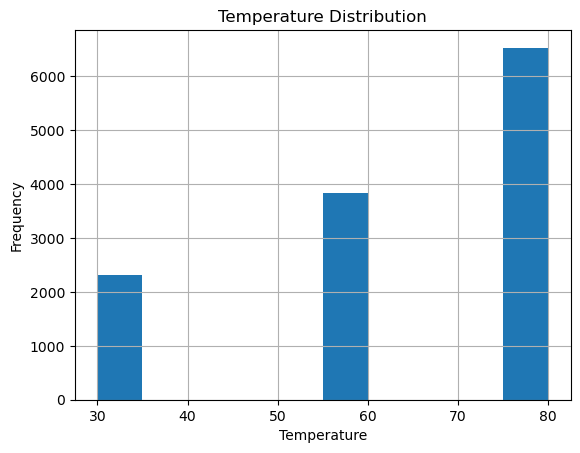

In [99]:
data['temperature'].hist()
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [145]:
data_bar = data[data['coupon'] == 'Bar']
data_bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [151]:
num_use_bar_coupon = (data_bar['Y'] == 1).sum()
total_bar = len(data_bar)
print(num_use_bar_coupon, total_bar)
ratio = (num_use_bar_coupon / total_bar) * 100
print('Percentage of data where coupon accepted for a bar: ', ratio, '%')

827 2017
Percentage of data where coupon accepted for a bar:  41.00148735746158 %


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


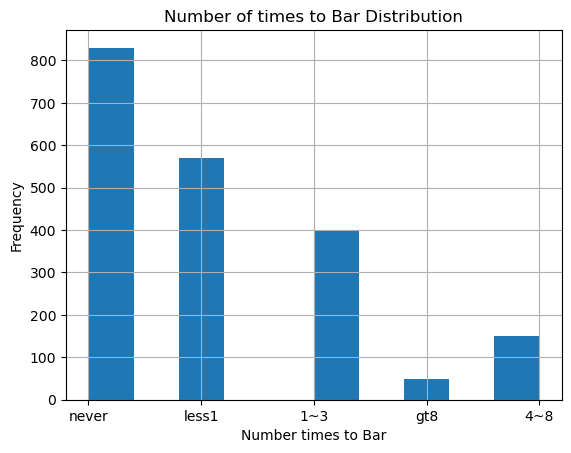

Bar
never    830
less1    570
1~3      397
4~8      150
gt8       49
Name: count, dtype: int64
1996
Drivers who accept a bar coupon who go to bars less than or equal to 3 times per month 37.061769616026716 %
Drivers who accept a bar coupon who go to bars more than 3 times per month 76.88442211055276 %
Drivers who go to bars greater than 3 times a month vs. those who go less are  2.0744940920820314  times more likely to accept the coupon


In [183]:
# Using histogram to explore the possible frequencies of number times going to a bar
data_bar['Bar'].hist()
plt.title('Number of times to Bar Distribution')
plt.xlabel('Number times to Bar')
plt.ylabel('Frequency')
plt.show()

print(data_bar['Bar'].value_counts(dropna=False))
# Since we see 21 NaN for Bar column, drop those rows
data_bar = data_bar.dropna(subset=['Bar'])
print(len(data_bar))

# New df with Bar coupon and goes to a bar 3 or fewer times a month
filter_bar_freq_lte_3 = data_bar[data_bar['Bar'].isin(['never', 'less1', '1~3'])]
num_use_bar_coupon_freq_lte_3 = (filter_bar_freq_lte_3['Y'] == 1).sum()
pct_bar_coupon_freq_lte_3 = (num_use_bar_coupon_freq_lte_3 / len(filter_bar_freq_lte_3)) * 100
print('Drivers who accept a bar coupon who go to bars less than or equal to 3 times per month', pct_bar_coupon_freq_lte_3, '%')
#print('filtered lte 3', num_use_bar_coupon_freq_lte_3, len(filter_bar_freq_lte_3))

# New df with Bar coupon and goes to a bar more than 3 times a month
filter_bar_freq_gt_3 = data_bar[~data_bar['Bar'].isin(['never', 'less1', '1~3'])]
num_use_bar_coupon_freq_gt_3 = (filter_bar_freq_gt_3['Y'] == 1).sum()
pct_bar_coupon_freq_gt_3 = (num_use_bar_coupon_freq_gt_3 / len(filter_bar_freq_gt_3)) * 100
print('Drivers who accept a bar coupon who go to bars more than 3 times per month', pct_bar_coupon_freq_gt_3, '%')
#print('filtered lte 3', num_use_bar_coupon_freq_lte_3, len(filter_bar_freq_lte_3))

# Ratio of acceptance rate of those going to the bar 3 times or less vs. those who went more
print('Drivers who go to bars greater than 3 times a month vs. those who go less are ', pct_bar_coupon_freq_gt_3/pct_bar_coupon_freq_lte_3, ' times more likely to accept the coupon' )

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [203]:
print('Unique Bar', data_bar['Bar'].unique())
print('Unique Age', data_bar['age'].unique())

# Filter by those who go to the bar more than once a month and over age 25
filter_bar_freq_gt_1_over_25 = data_bar[
    (~data_bar['Bar'].isin(['never','less1'])) &
    (~data_bar['age'].isin(['21','below21']))
]
total_bar_coupon_gt_1_over_25 = len(filter_bar_freq_gt_1_over_25)
num_use_bar_coupon_freq_gt_1_over_25 = (filter_bar_freq_gt_1_over_25['Y'] == 1).sum()
pct_bar_coupon_freq_gt_1_over_25 = num_use_bar_coupon_freq_gt_1_over_25 / total_bar_coupon_gt_1_over_25 * 100
print('Drivers who accept a bar coupon who go to bars more than once a month and over age 25: ', pct_bar_coupon_freq_gt_1_over_25, '%')

# Filter by those who go to the bar more than once a month and over age 25
filter_bar_freq_lte_1_under_25 = data_bar[
    (data_bar['Bar'].isin(['never','less1'])) &
    (data_bar['age'].isin(['21','below21']))
]
total_bar_coupon_lte_1_under_25 = len(filter_bar_freq_lte_1_under_25)
num_use_bar_coupon_freq_lte_1_underr_25 = (filter_bar_freq_lte_1_under_25['Y'] == 1).sum()
pct_bar_coupon_freq_lte_1_under_25 = num_use_bar_coupon_freq_lte_1_underr_25 / total_bar_coupon_lte_1_under_25 * 100
print('Drivers who accept a bar coupon who go to bars more than once a month and over age 25: ', pct_bar_coupon_freq_lte_1_under_25, '%')
print('Drivers who go to bars more than once a month and over the age of 25 vs. all others ', pct_bar_coupon_freq_gt_1_over_25/pct_bar_coupon_freq_lte_1_under_25, ' times more likely to accept the coupon' )

Unique Bar ['never' 'less1' '1~3' 'gt8' '4~8']
Unique Age ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
Drivers who accept a bar coupon who go to bars more than once a month and over age 25:  69.52380952380952 %
Drivers who accept a bar coupon who go to bars more than once a month and over age 25:  39.44954128440367 %
Drivers who go to bars more than once a month and over the age of 25 vs. all others  1.76234772978959  times more likely to accept the coupon


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [216]:
# We have 596 bar coupons where cusotmer goes to bars more than once a month
print('Total number of drivers who got bar coupons who go to bars more than once a month: ', len(data_bar_filtered))
print('Unique passanger', data_bar['passanger'].unique())
print('Unique occupation', data_bar['occupation'].unique())
print()

# Filter by those who go to the bar more than once a month and passengers not a kid and occupation other than farming,fishing, or forestry
filter_bar_freg_gt1_passenger_notKid_occupation_notFFF = data_bar[
    (~data_bar['Bar'].isin(['never','less1'])) &
    (~data_bar['passanger'].isin(['Kid(s)'])) &
    (~data_bar['occupation'].isin(['Farming Fishing & Forestry']))
]
total_freg_gt1_passenger_notKid_occupation_notFFF = len(filter_bar_freg_gt1_passenger_notKid_occupation_notFFF)
num_coupon_freg_gt1_passenger_notKid_occupation_notFFF = (filter_bar_freg_gt1_passenger_notKid_occupation_notFFF['Y'] == 1).sum()
pct_coupon_freg_gt1_passenger_notKid_occupation_notFFF = num_coupon_freg_gt1_passenger_notKid_occupation_notFFF / total_freg_gt1_passenger_notKid_occupation_notFFF * 100
print('Drivers who accept a bar coupon who go to bars more than once a month, no kids as passengers, no job as Farm Fishing & Forestry: ',
      pct_coupon_freg_gt1_passenger_notKid_occupation_notFFF, '%')

# data_bar_diff is all others
data_bar_diff = data_bar.loc[~data_bar.index.isin(filter_bar_freg_gt1_passenger_notKid_occupation_notFFF.index)]
#print(len(data_bar), len(filter_bar_freg_gt1_passenger_notKid_occupation_notFFF), len(data_bar_diff))
total_all_other = len(data_bar_diff)
num_coupon_all_other = (data_bar_diff['Y'] == 1).sum()
pct_coupon_all_other = num_coupon_all_other / total_all_other * 100
#print(total_all_other, num_coupon_all_other, pct_coupon_all_other)
print('All other drivers: ',
      pct_coupon_all_other, '%')

print('Drivers who accept a bar coupon who go to bars more than once a month, no kids as passengers, no job as Farm Fishing & Forestry vs. all others are ', pct_coupon_freg_gt1_passenger_notKid_occupation_notFFF/pct_coupon_all_other,' times more likely to accept the coupon') 


Total number of drivers who got bar coupons who go to bars more than once a month:  596
Unique passanger ['Kid(s)' 'Alone' 'Friend(s)' 'Partner']
Unique occupation ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 'Transportation & Material Moving'
 'Business & Financial' 'Protective Service'
 'Food Preparation & Serving Related' 'Production Occupations'
 'Building & Grounds Cleaning & Maintenance' 'Farming Fishing & Forestry']

Drivers who accept a bar coupon who go to bars more than once a month, no kids as passengers, no job as Farm Fishing & Forestry:  71.32486388384754 %
All other drive

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [231]:
# Filter by those who meet all 3 bulleted criteria
print('Unique marital status', data_bar['maritalStatus'].unique())
print('Unique cheap restaurant', data_bar['RestaurantLessThan20'].unique())
print('Unique income', data_bar['income'].unique())
print()

def acceptance_rate(filtered_df, label=""):
    total = len(filtered_df)
    
    if total == 0:
        print(f"{label} → No data available")
        return None
    
    accepted = (filtered_df['Y'] == 1).sum()
    pct = (accepted / total) * 100
    
    print(f"{label} → Coupon acceptance rate: {pct:.2f}%")
    #return pct

# Bullet 1
filter_bar_gt1_pass_noKids_not_widowed = data_bar[
    (~data_bar['Bar'].isin(['never','less1'])) &
    (~data_bar['passanger'].isin(['Kid(s)'])) &
    (~data_bar['maritalStatus'].isin(['Widowed']))
]
acceptance_rate(filter_bar_gt1_pass_noKids_not_widowed, 
                'Go to bars more than once a month, had passengers that were not a kid, and were not widowed')
# Bullet 2
filter_bar_gt1_pass_under30 = data_bar[
    (~data_bar['Bar'].isin(['never','less1'])) &
    (data_bar['age'].isin(['21', 'below21']))
]
acceptance_rate(filter_bar_gt1_pass_under30, 
                'Go to bars more than once a month and are under the age of 30')
# Bullet 3
filter_cheapRest_gt4_inc_lt50K = data_bar[
    (data_bar['RestaurantLessThan20'].isin(['4~8','gt8'])) &
    (data_bar['income'].isin(['Less than $12500', '$12500 - $24999','$25000 - $37499', '$37500 - $49999']))
]
acceptance_rate(filter_cheapRest_gt4_inc_lt50K, 
                'Go to cheap restaurants more than 4 times a month and income is less than 50K')


Unique marital status ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
Unique cheap restaurant ['4~8' '1~3' 'less1' 'gt8' nan 'never']
Unique income ['$37500 - $49999' '$62500 - $74999' '$12500 - $24999' '$75000 - $87499'
 '$50000 - $62499' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']

Go to bars more than once a month, had passengers that were not a kid, and were not widowed → Coupon acceptance rate: 71.32%
Go to bars more than once a month and are under the age of 30 → Coupon acceptance rate: 67.05%
Go to cheap restaurants more than 4 times a month and income is less than 50K → Coupon acceptance rate: 45.72%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [248]:
print('Drivers who go to bars more than once a month who are driving around without a kid in their car and not widowed have the highest coupon acceptance rate of the three scenarios; followed by drivers who go to bars more than once a month and under 30.')
print('The under 30 drivers makes sense that they can be more spontaneous to go to a bar without much rearranging of their schedules.')
print('The folks with a lower income frequenting cheaper restaurant probably do not want to waste money at a bar')
print('Makes sense that they have the lowest acceptance rate.')

Drivers who go to bars more than once a month who are driving around without a kid in their car and not widowed have the highest coupon acceptance rate of the three scenarios; followed by drivers who go to bars more than once a month and under 30.
The under 30 drivers makes sense that they can be more spontaneous to go to a bar without much rearranging of their schedules.
The folks with a lower income frequenting cheaper restaurant probably do not want to waste money at a bar
Makes sense that they have the lowest acceptance rate.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [276]:
# Investigate Coffee Houses
data_coffee = data[data['coupon'] == 'Coffee House']
data_coffee.head()
# Peek at the ones with accepted coupons
data_coffee_accepted = data_coffee[data_coffee['Y'] == 1]
data_coffee_accepted.head(1996)
#print(len(data_coffee_accepted))

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
16,Work,Alone,Sunny,55,7AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,1
21,Work,Alone,Sunny,55,7AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
45,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,1
48,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12579,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,21,Single,...,never,1~3,1~3,less1,1,0,0,1,0,1
12601,Home,Alone,Rainy,55,10PM,Coffee House,2h,Female,50plus,Divorced,...,less1,1~3,1~3,less1,1,0,0,1,0,1
12608,Work,Alone,Snowy,30,7AM,Coffee House,1d,Female,50plus,Divorced,...,less1,1~3,1~3,less1,1,0,0,1,0,1
12624,Home,Alone,Rainy,55,10PM,Coffee House,2h,Female,21,Unmarried partner,...,4~8,1~3,1~3,less1,1,0,0,1,0,1


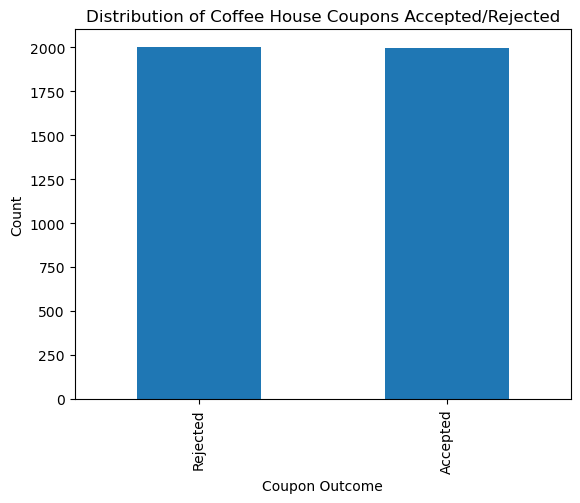

In [251]:
labels = {
    1: 'Accepted',
    0: 'Rejected'
}

data_coffee['Y'].map(labels).value_counts().plot(kind='bar')
plt.title('Distribution of Coffee House Coupons Accepted/Rejected')
plt.xlabel('Coupon Outcome')
plt.ylabel('Count')
plt.show()

print('Bar chart shows the number of accepted vs. reject coffee house coupons is about the same.')

Coffee coupon - Female with no place urgent to go → Coupon acceptance rate: 59.08%


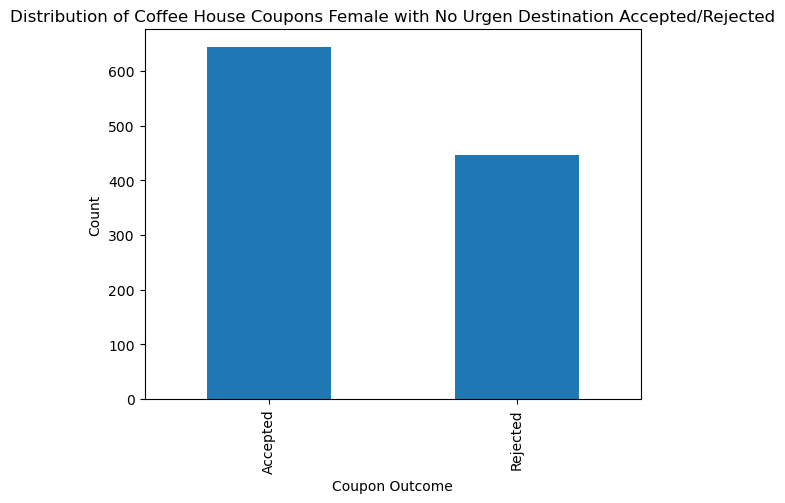

In [258]:
filter_coffee_female_noUrgentPlace = data_coffee[
    (data_coffee['gender'].isin(['Female'])) &
    (data_coffee['destination'].isin(['No Urgent Place']))
]
filter_coffee_female_noUrgentPlace['Y'].map(labels).value_counts().plot(kind='bar')
plt.title('Distribution of Coffee House Coupons Female with No Urgen Destination Accepted/Rejected')
plt.xlabel('Coupon Outcome')
plt.ylabel('Count')
plt.show
acceptance_rate(filter_coffee_female_noUrgentPlace, 'Coffee coupon - Female with no place urgent to go')

Coffee coupon - Female with no place urgent to go and sunny → Coupon acceptance rate: 58.93%


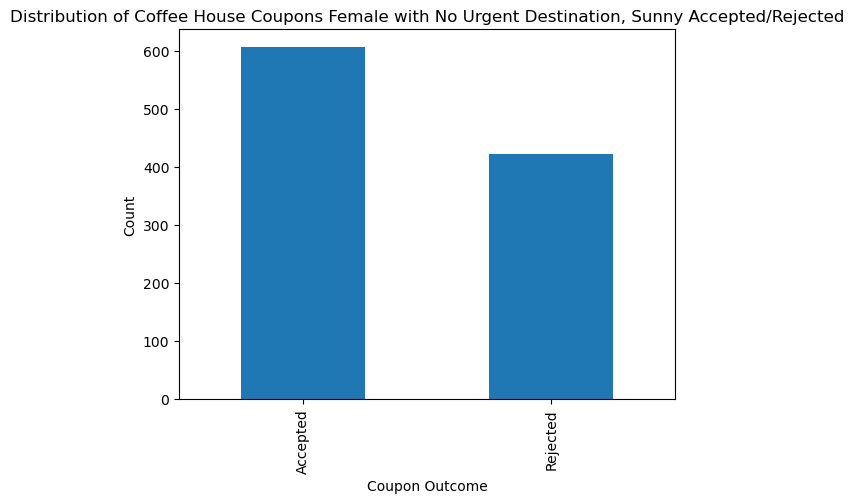

In [262]:
filter_coffee_female_noUrgentPlace_sunny = data_coffee[
    (data_coffee['gender'].isin(['Female'])) &
    (data_coffee['destination'].isin(['No Urgent Place'])) &
    (data_coffee['weather'].isin(['Sunny']))
]
filter_coffee_female_noUrgentPlace_sunny['Y'].map(labels).value_counts().plot(kind='bar')
plt.title('Distribution of Coffee House Coupons Female with No Urgent Destination, Sunny Accepted/Rejected')
plt.xlabel('Coupon Outcome')
plt.ylabel('Count')
plt.show
acceptance_rate(filter_coffee_female_noUrgentPlace_sunny, 'Coffee coupon - Female with no place urgent to go and sunny')

Unique time ['10AM' '2PM' '6PM' '7AM' '10PM']
Coffee coupon - Female with no place urgent to go and sunny and early AM → Coupon acceptance rate: 64.95%


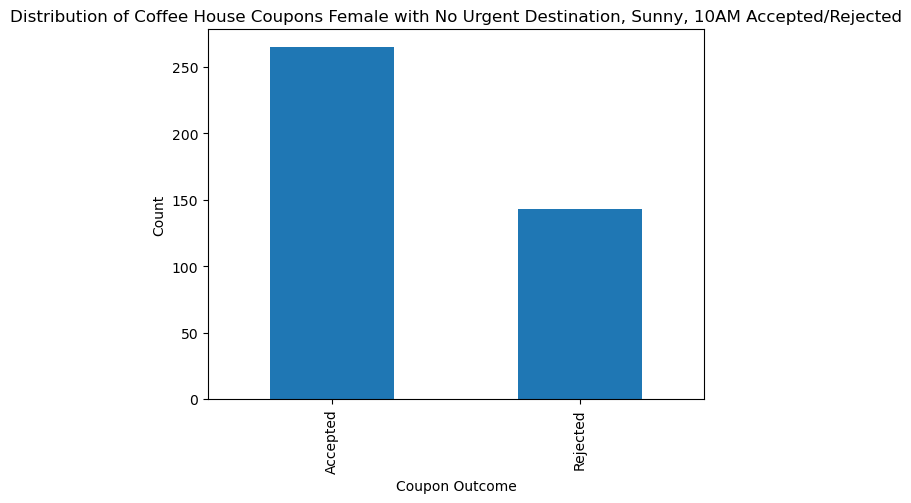

In [268]:
print('Unique time', data_coffee['time'].unique())
filter_coffee_female_noUrgentPlace_sunny_AM = data_coffee[
    (data_coffee['gender'].isin(['Female'])) &
    (data_coffee['destination'].isin(['No Urgent Place'])) &
    (data_coffee['weather'].isin(['Sunny'])) &
    (data_coffee['time'].isin(['7AM','10AM']))
]
filter_coffee_female_noUrgentPlace_sunny_AM['Y'].map(labels).value_counts().plot(kind='bar')
plt.title('Distribution of Coffee House Coupons Female with No Urgent Destination, Sunny, 10AM Accepted/Rejected')
plt.xlabel('Coupon Outcome')
plt.ylabel('Count')
plt.show
acceptance_rate(filter_coffee_female_noUrgentPlace_sunny_AM, 'Coffee coupon - Female with no place urgent to go and sunny and early AM')

Unique times coffee house ['never' 'less1' '4~8' '1~3' 'gt8' nan]
Coffee coupon - Female with no place urgent to go and sunny and 10AM and goes to coffee houses at least once a month → Coupon acceptance rate: 83.73%


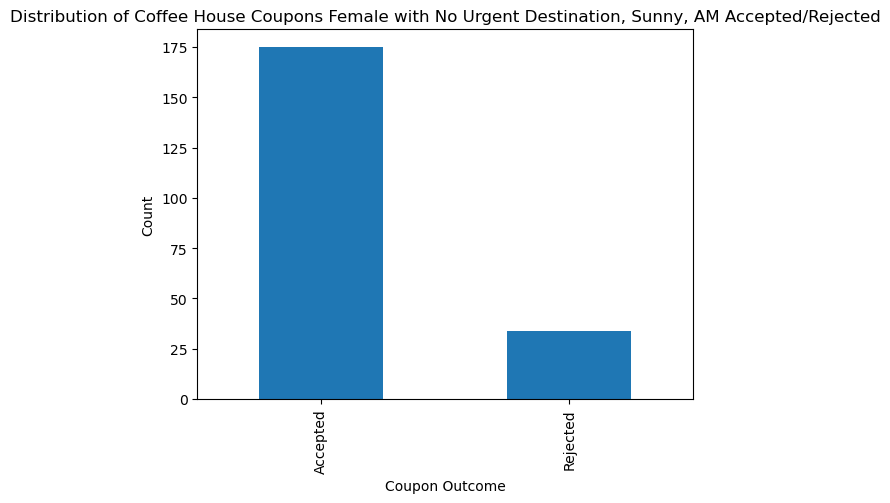

In [270]:
print('Unique times coffee house', data_coffee['CoffeeHouse'].unique())
filter_coffee_female_noUrgentPlace_sunny_AM_freq = data_coffee[
    (data_coffee['gender'].isin(['Female'])) &
    (data_coffee['destination'].isin(['No Urgent Place'])) &
    (data_coffee['weather'].isin(['Sunny'])) &
    (data_coffee['time'].isin(['7AM', '10AM']))&
    (~data_coffee['CoffeeHouse'].isin(['never', 'less1']))
]
filter_coffee_female_noUrgentPlace_sunny_AM_freq['Y'].map(labels).value_counts().plot(kind='bar')
plt.title('Distribution of Coffee House Coupons Female with No Urgent Destination, Sunny, AM Accepted/Rejected')
plt.xlabel('Coupon Outcome')
plt.ylabel('Count')
plt.show
acceptance_rate(filter_coffee_female_noUrgentPlace_sunny_AM_freq, 'Coffee coupon - Female with no place urgent to go and sunny and 10AM and goes to coffee houses at least once a month')